## Here we apply the effect percentage on each person rather than on the mu


Analyzing Dataset1_outliers_ready.csv with Manual T-Tests...


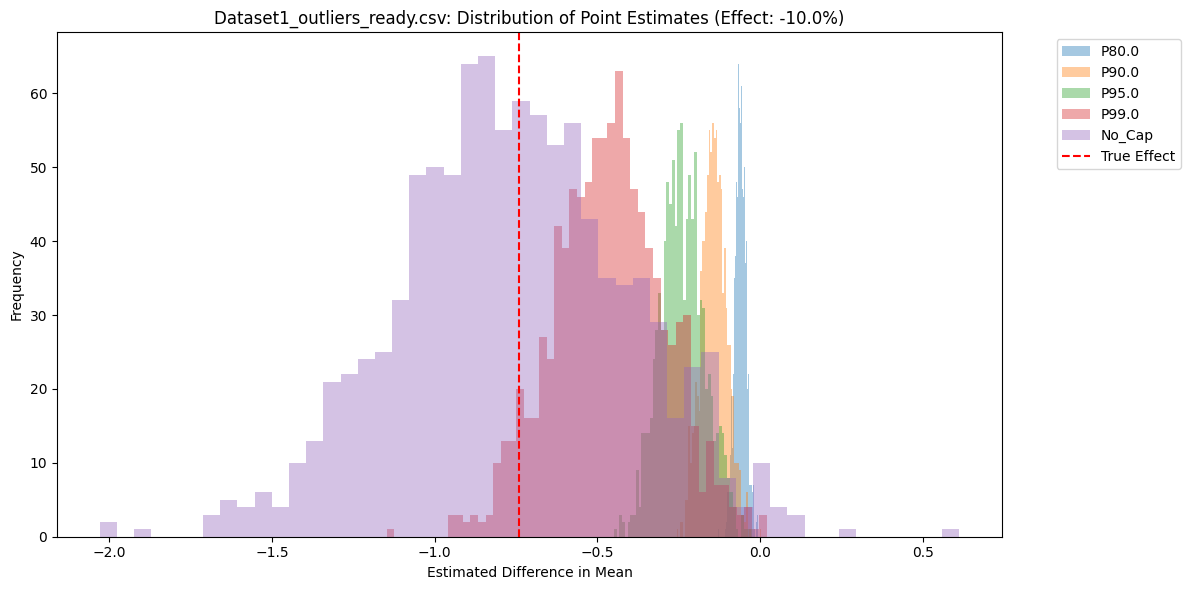

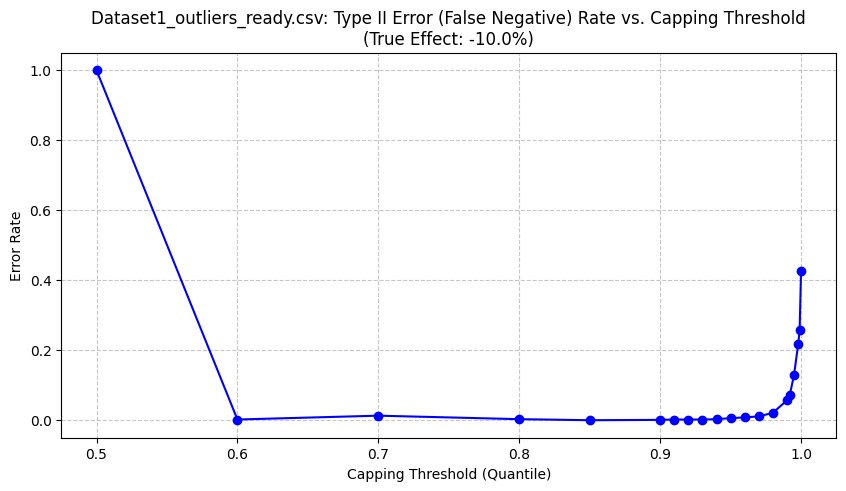

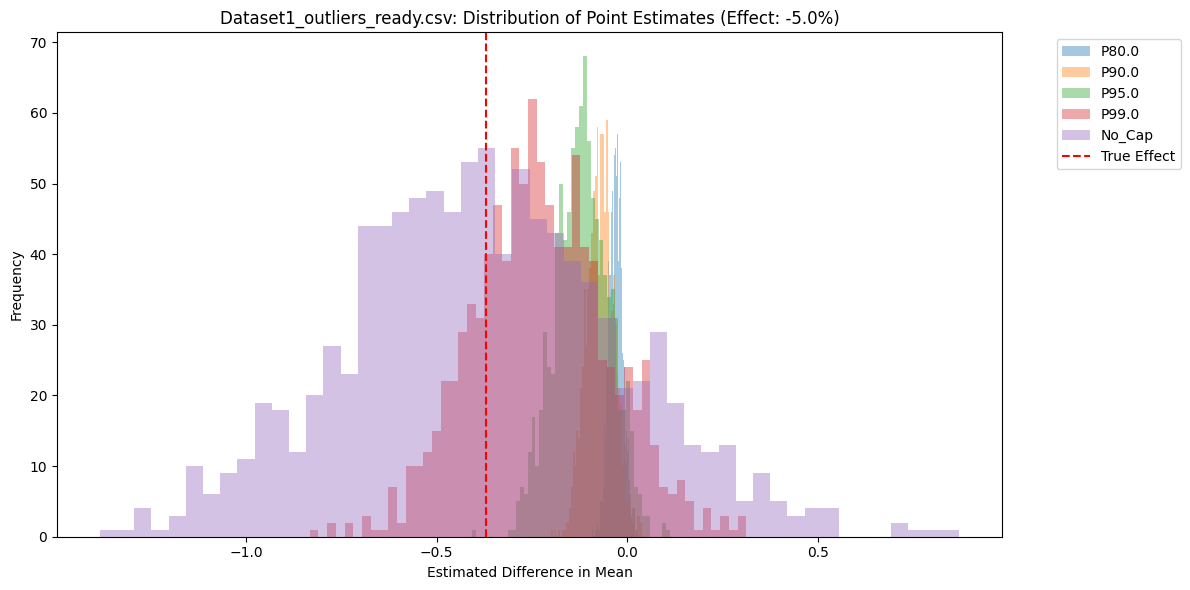

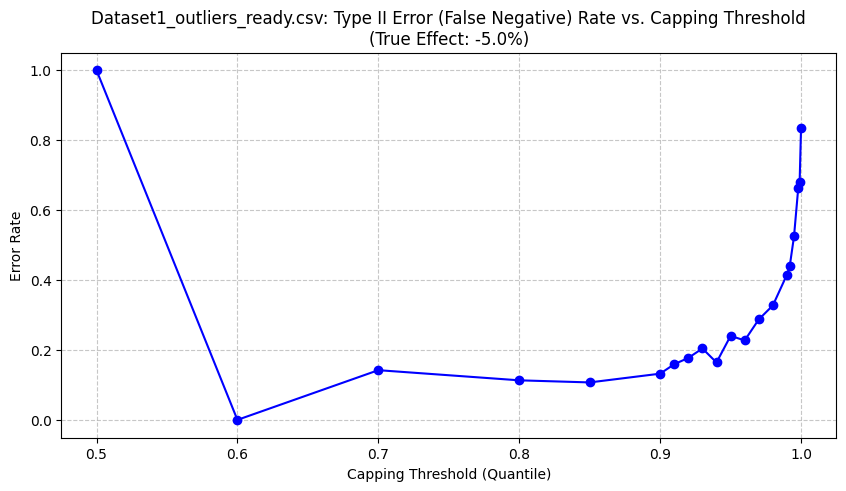

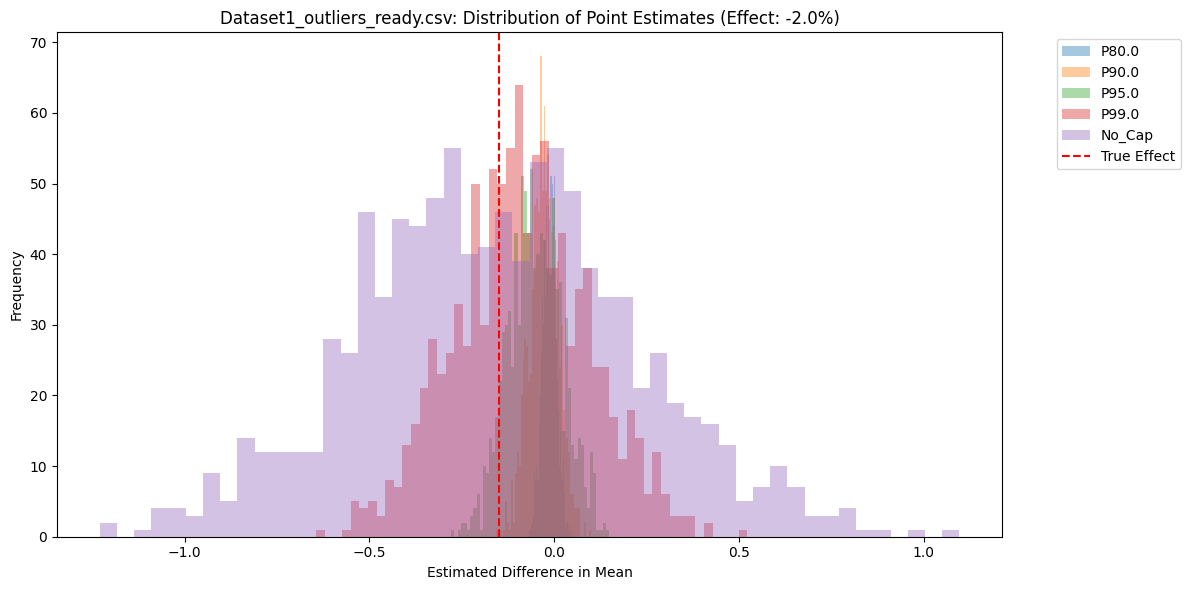

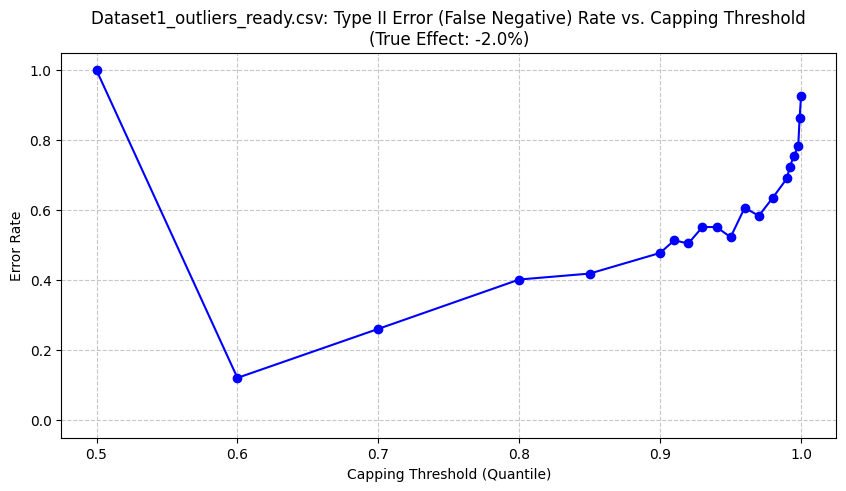

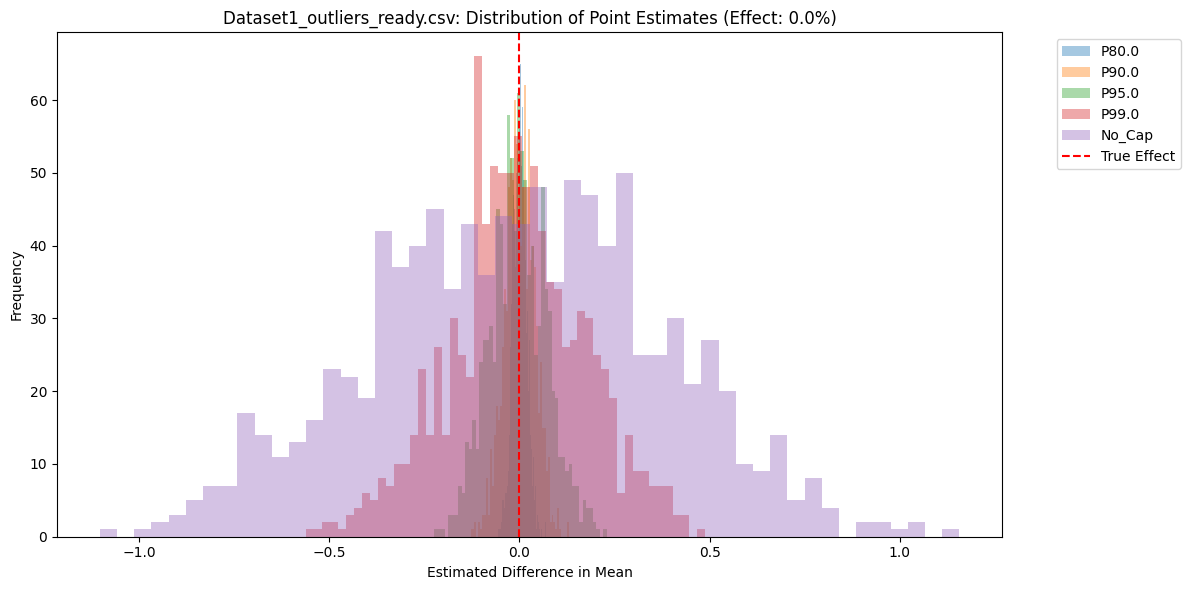

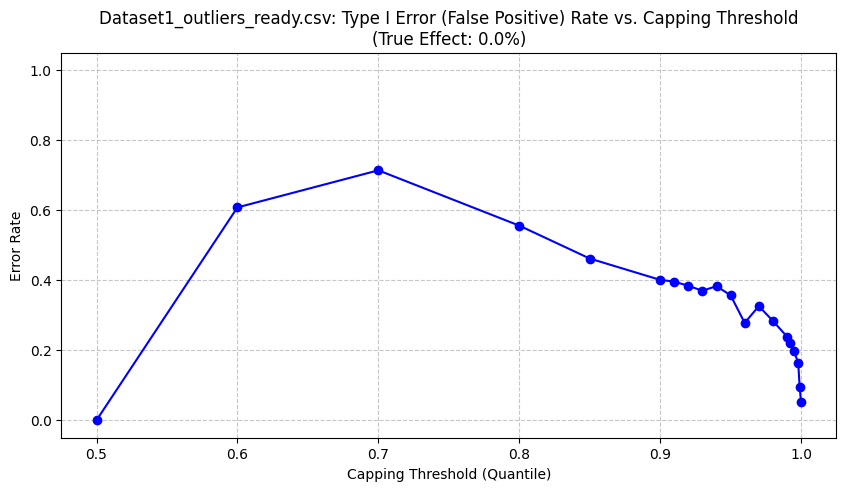

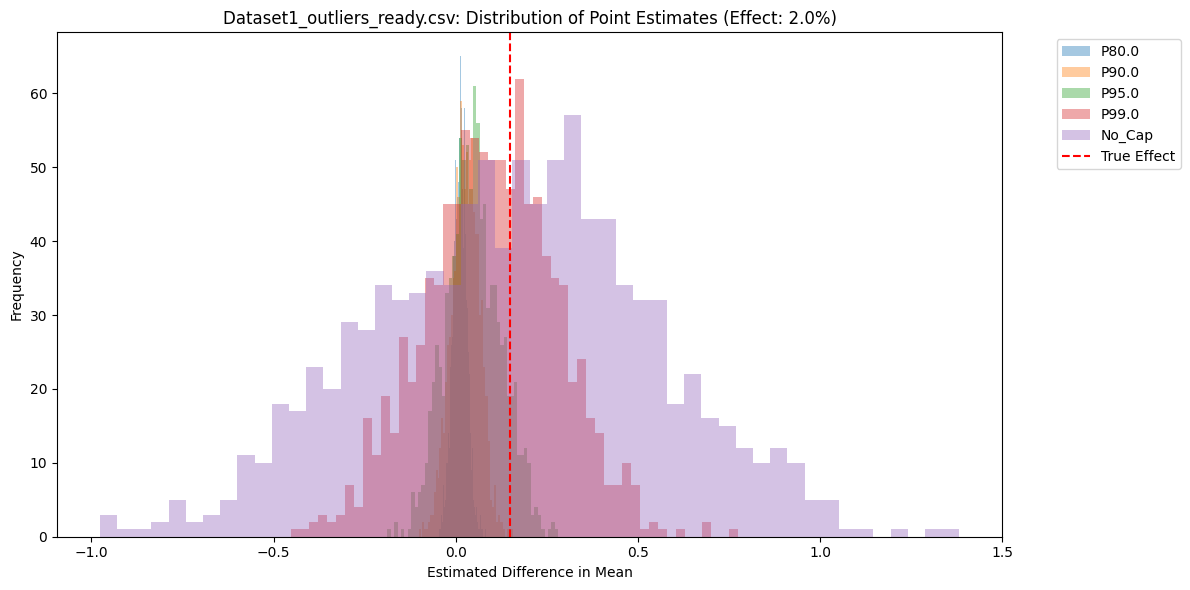

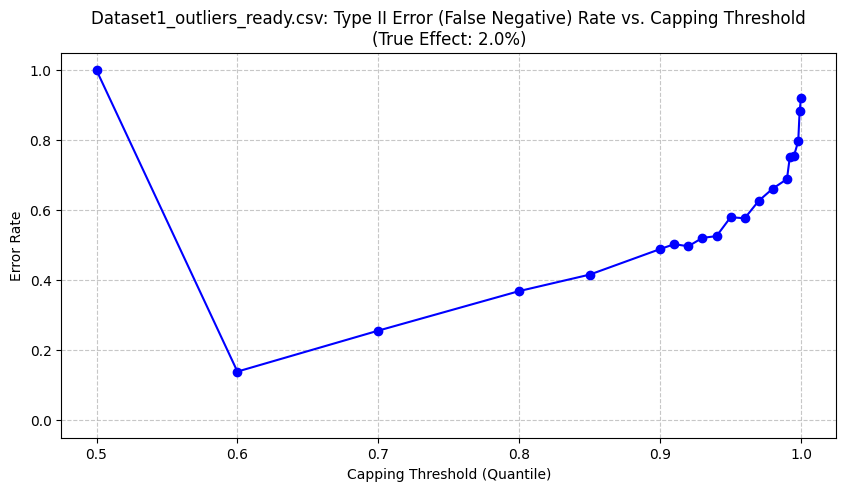

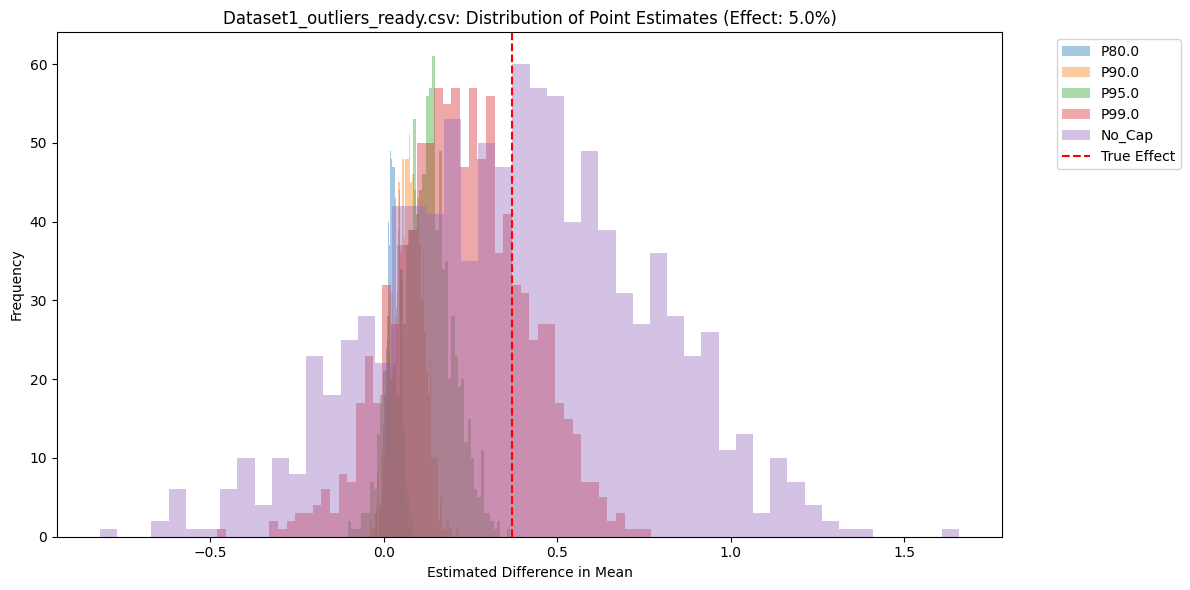

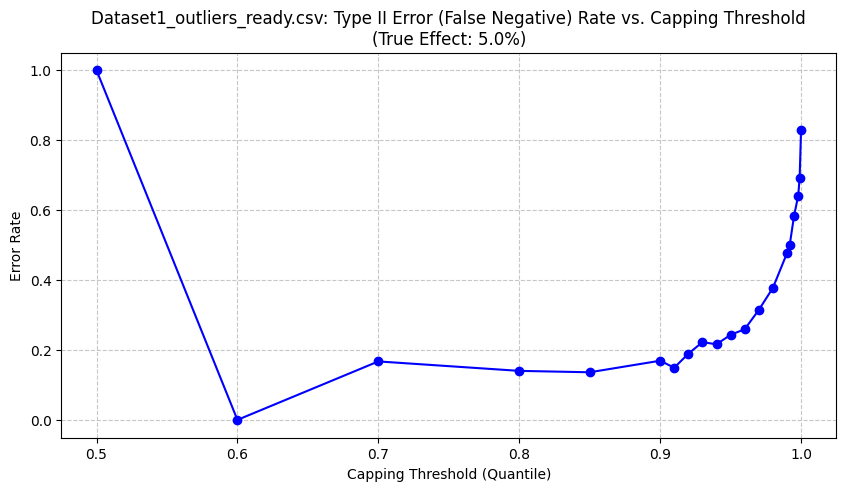

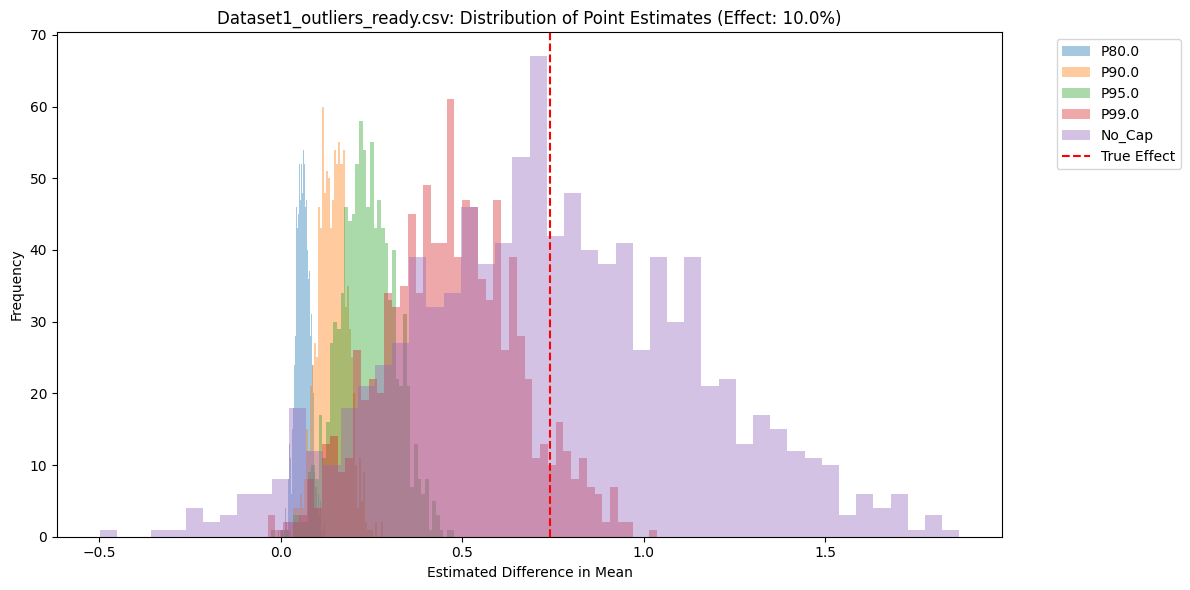

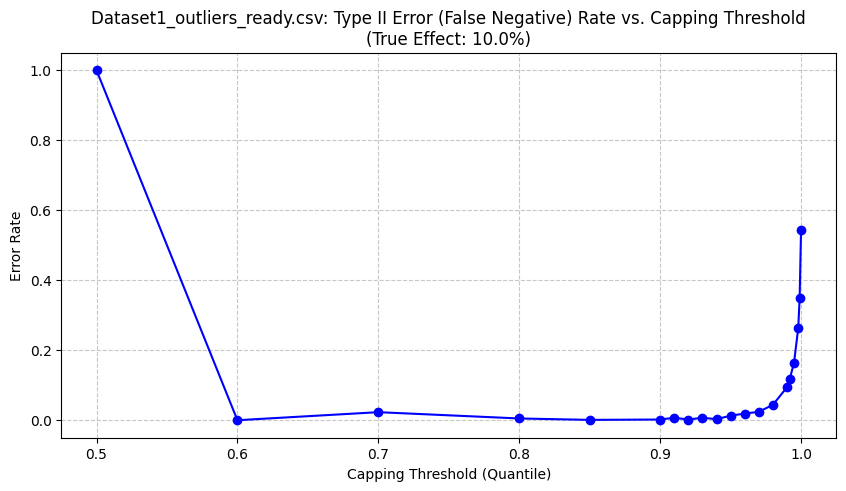

Saved Matrix to experiment1_Dataset1_outliers_ready.csv_matrix.csv
Saved Diagnostics to experiment1_Dataset1_outliers_ready.csv_diagnostics.csv

--- Meta-Analysis ---
Dataset: Dataset1_outliers_ready.csv
Sample_Size: 104113
Original_Mean: 7.4102
Cap Values ($): {'P50.0': 0.0, 'P60.0': 0.05, 'P70.0': 0.67, 'P80.0': 2.21, 'P85.0': 4.01, 'P90.0': 8.11, 'P91.0': 9.59, 'P92.0': 11.55, 'P93.0': 14.13, 'P94.0': 17.59, 'P95.0': 22.38, 'P96.0': 29.39, 'P97.0': 41.08, 'P98.0': 65.09, 'P99.0': 132.07, 'P99.2': 169.87, 'P99.5': 261.71, 'P99.8': 545.95, 'P99.9': 835.92, 'P100.0': inf}

--- Dataset1_outliers_ready.csv Error Matrix ---
 Actual_Effect_Value  P50.0  P60.0  P70.0  P80.0  P85.0  P90.0  P91.0  P92.0  P93.0  P94.0  P95.0  P96.0  P97.0  P98.0  P99.0  P99.2  P99.5  P99.8  P99.9  No_Cap
             -0.7410    1.0  0.002  0.013  0.003  0.000  0.001  0.002  0.002  0.002  0.003  0.006  0.008  0.011  0.021  0.057  0.072  0.129  0.218  0.258   0.427
             -0.3705    1.0  0.001  0.143  0.11

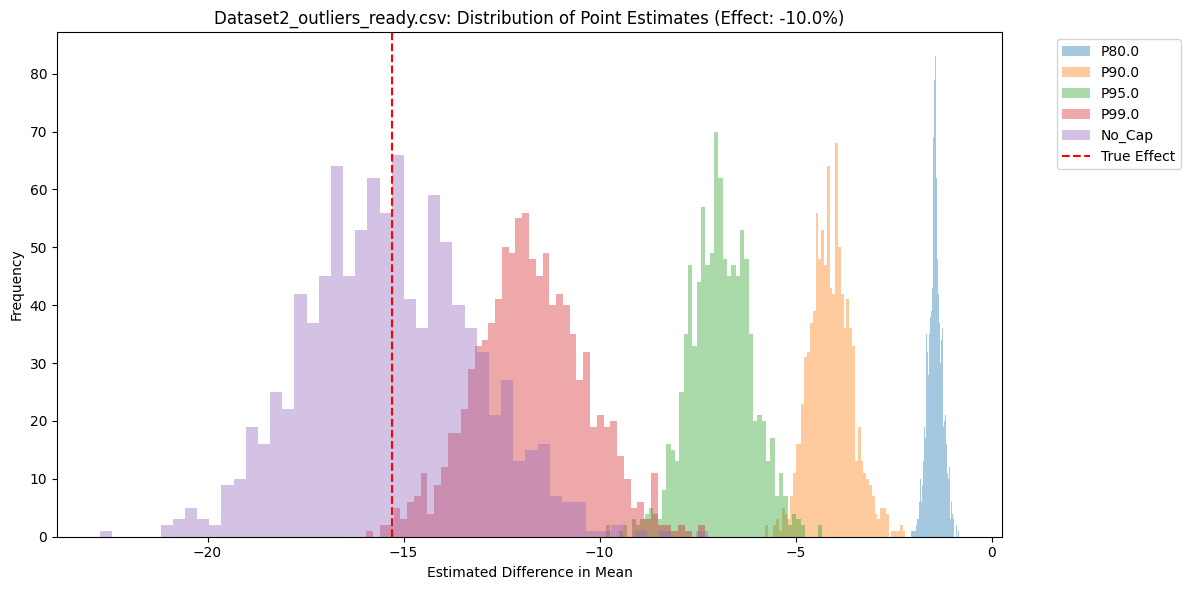

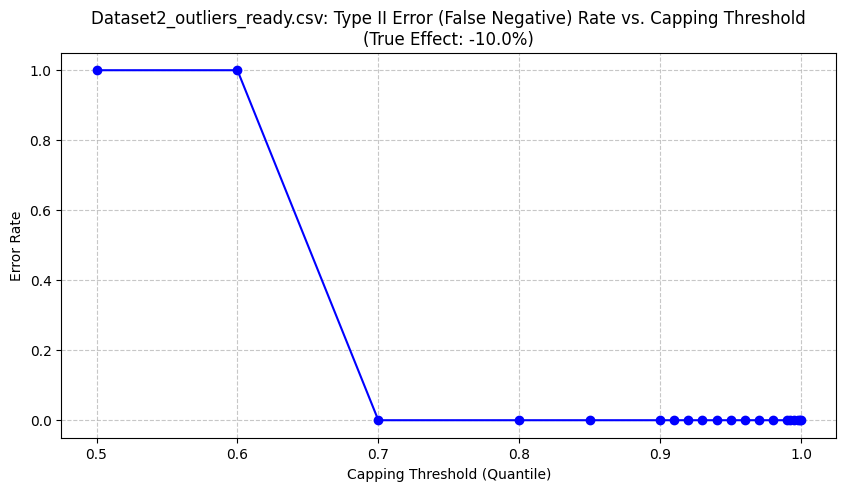

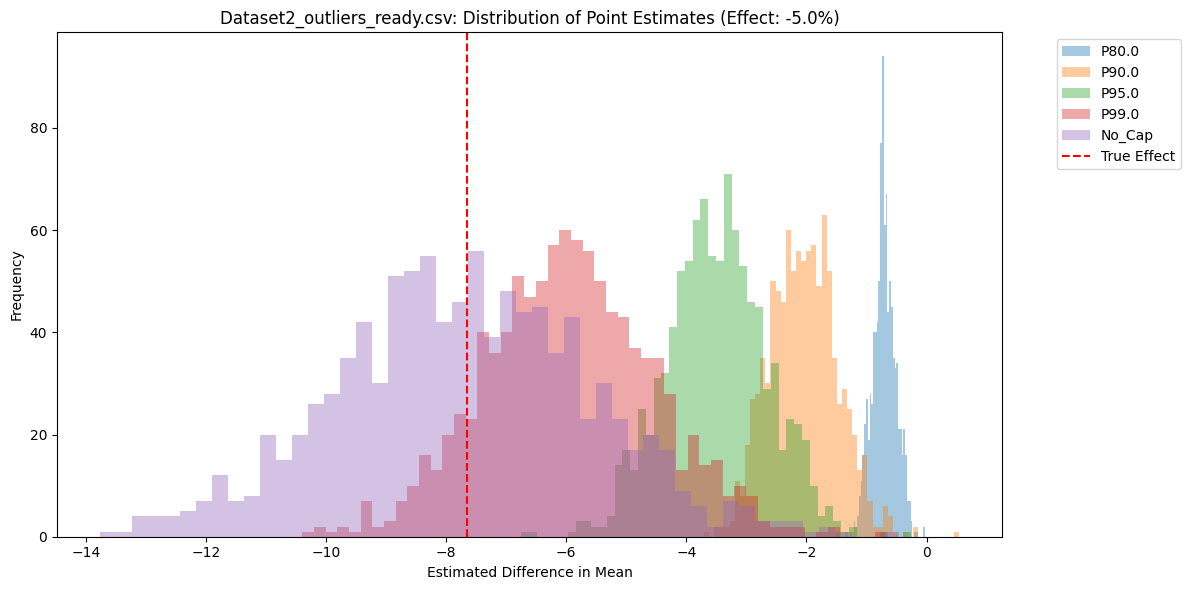

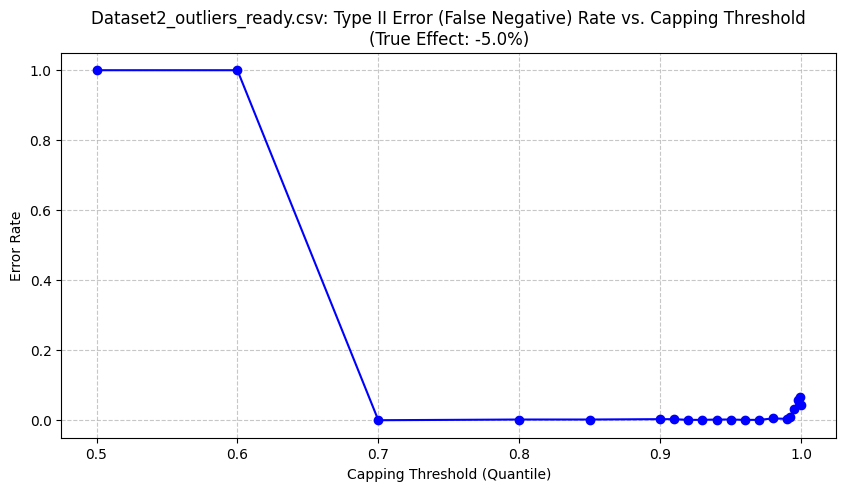

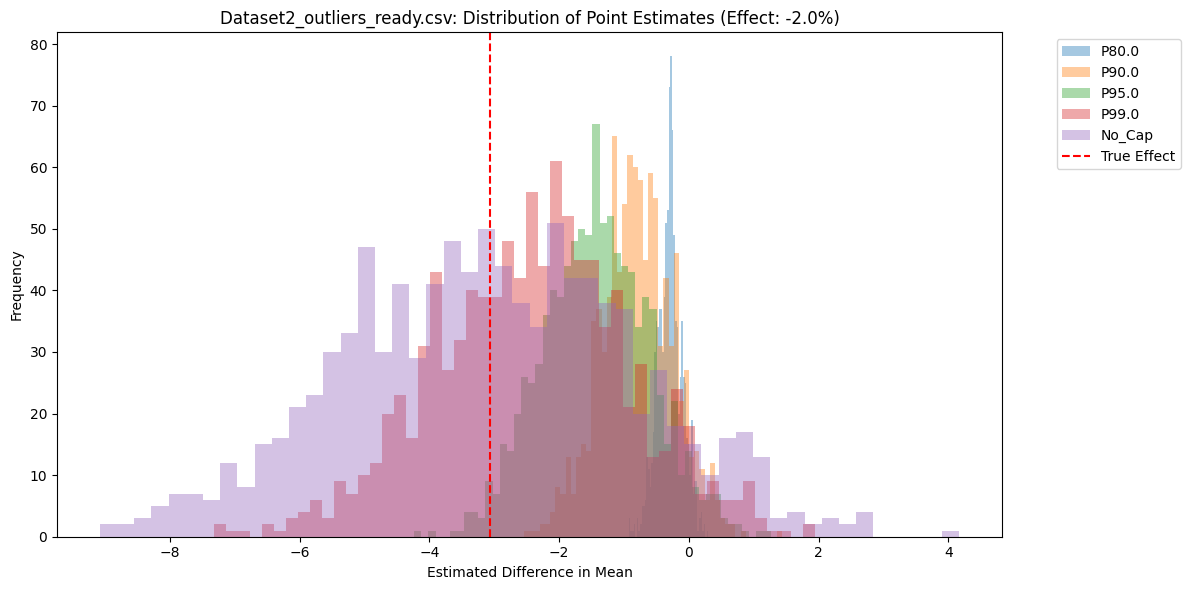

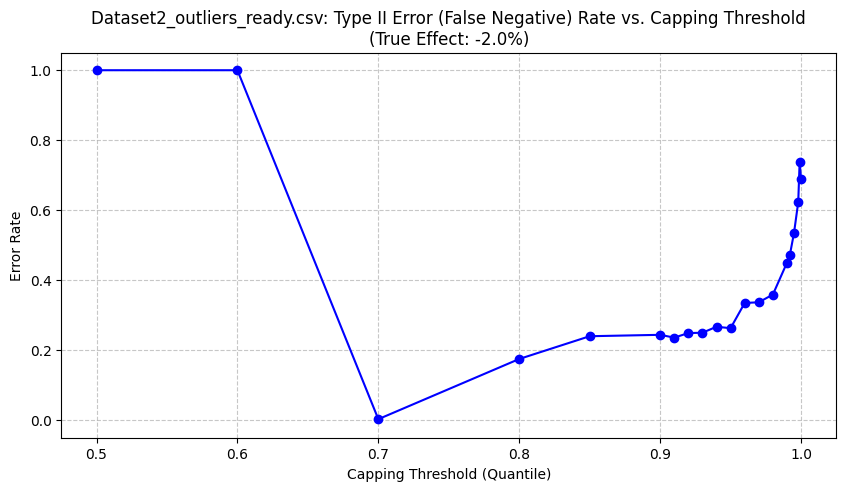

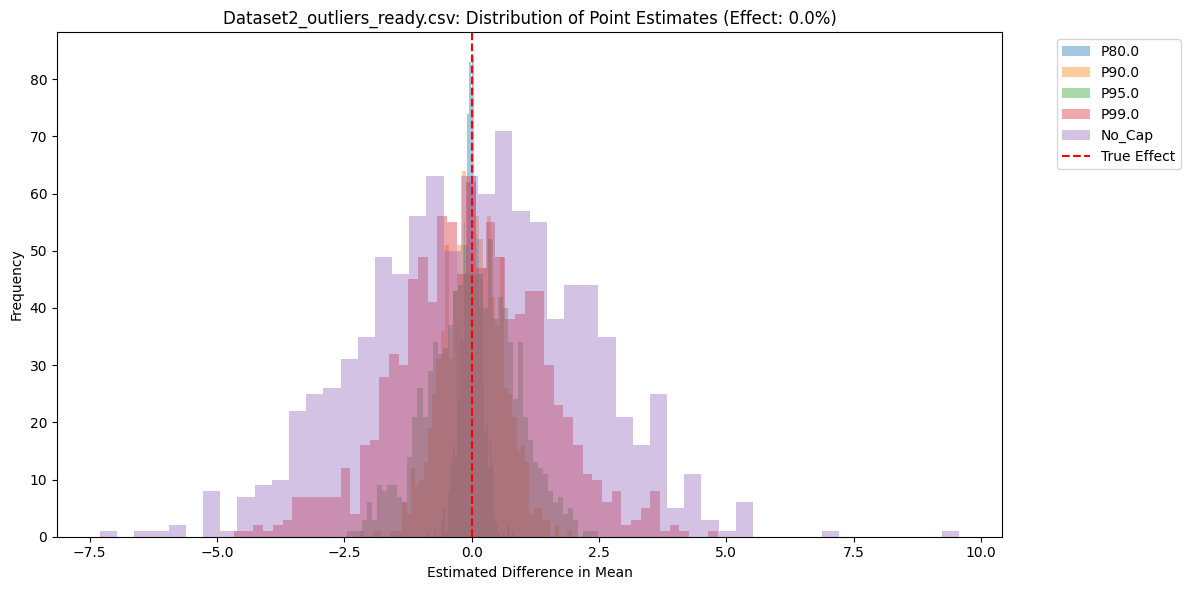

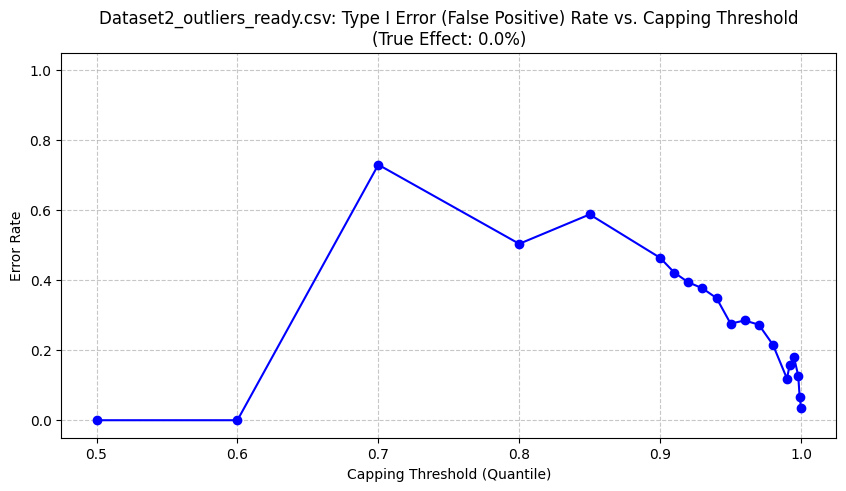

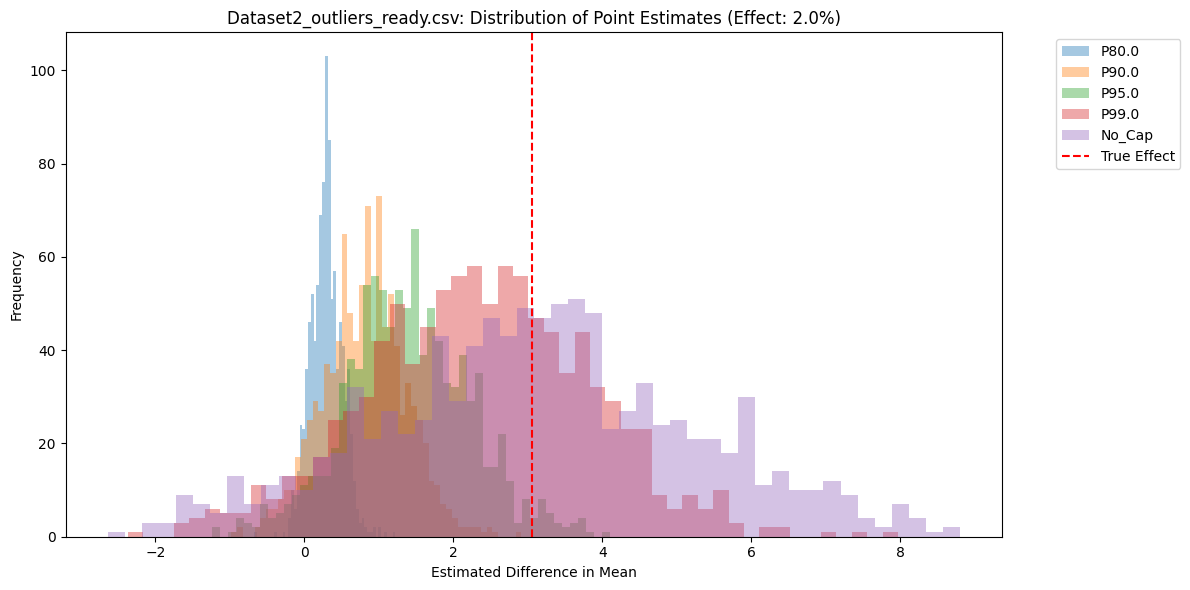

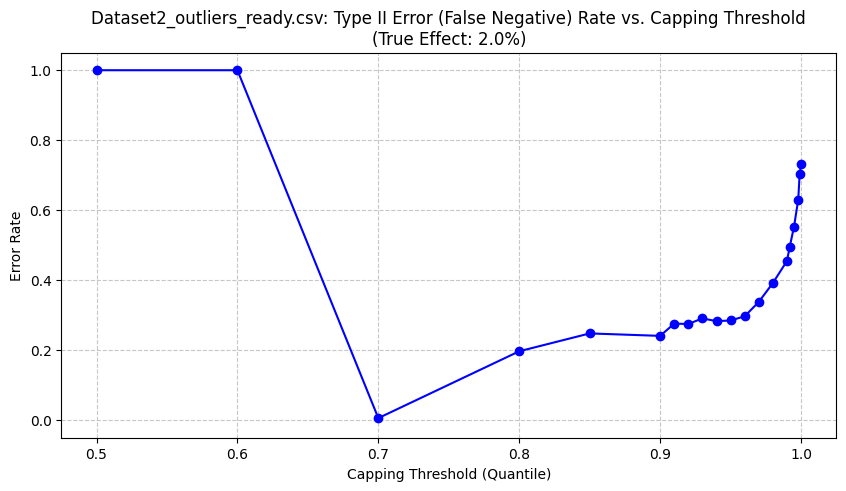

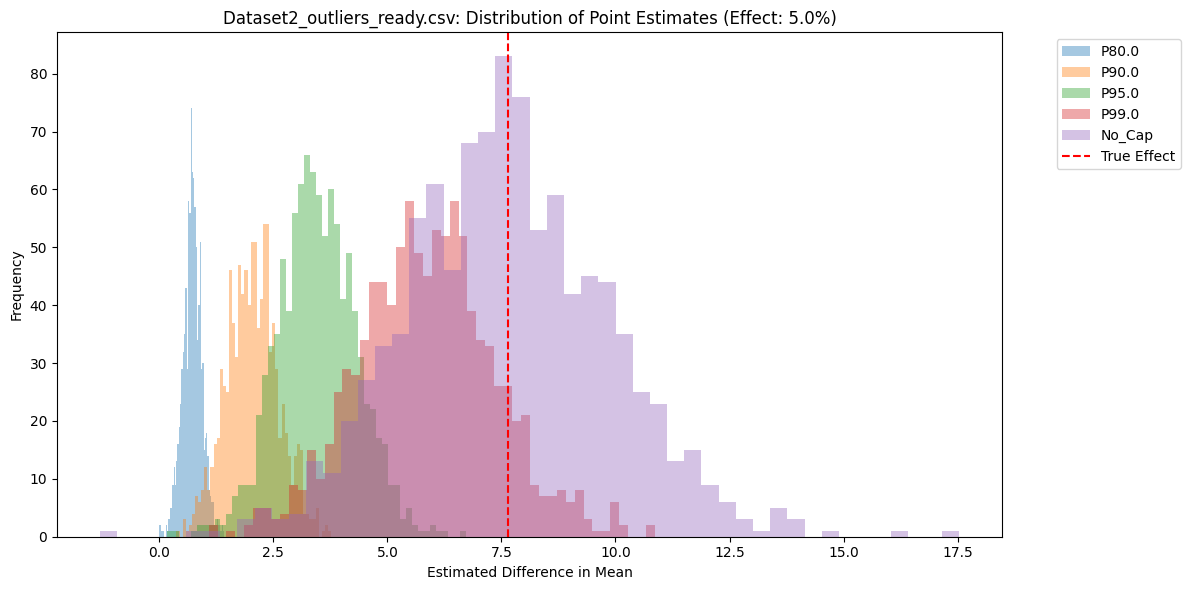

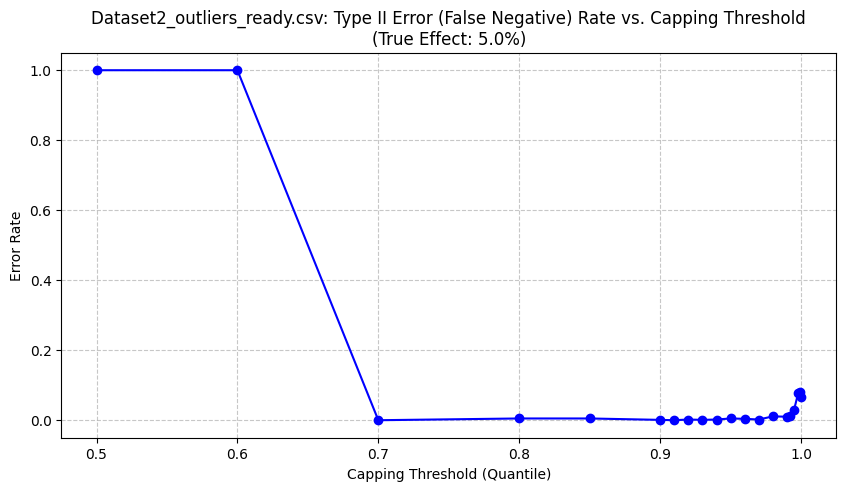

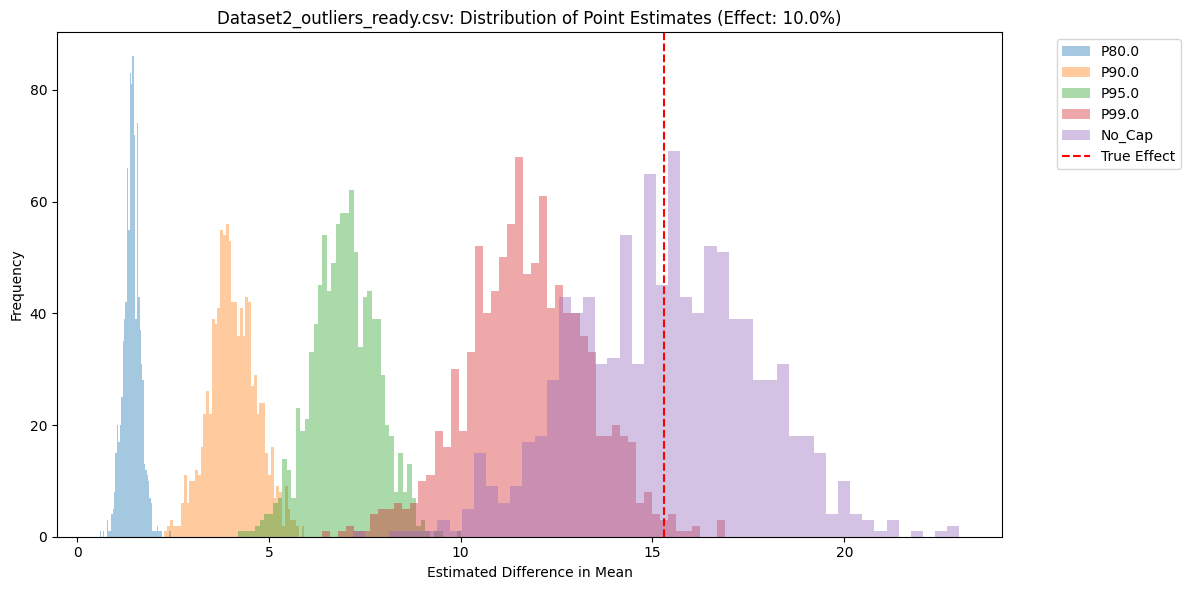

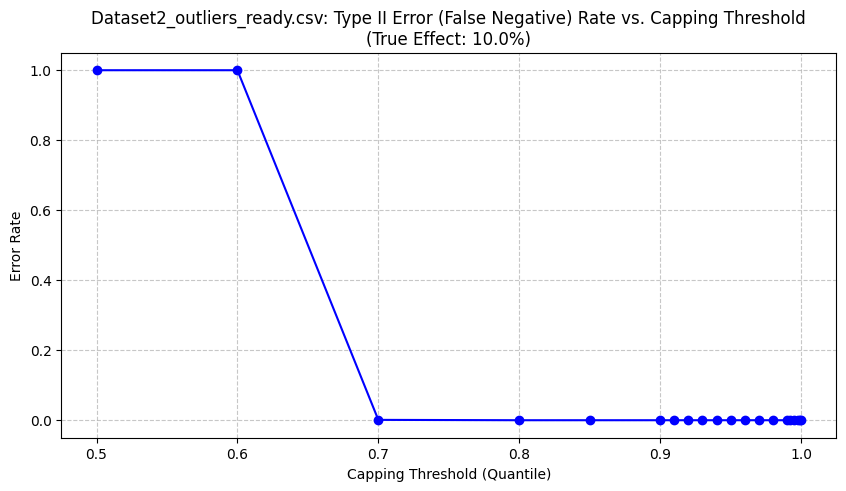

Saved Matrix to experiment2_Dataset2_outliers_ready.csv_matrix.csv
Saved Diagnostics to experiment2_Dataset2_outliers_ready.csv_diagnostics.csv

--- Meta-Analysis ---
Dataset: Dataset2_outliers_ready.csv
Sample_Size: 517129
Original_Mean: 153.06
Cap Values ($): {'P50.0': 0.0, 'P60.0': 0.0, 'P70.0': 13.06, 'P80.0': 55.01, 'P85.0': 113.08, 'P90.0': 249.62, 'P91.0': 296.91, 'P92.0': 355.32, 'P93.0': 427.38, 'P94.0': 524.07, 'P95.0': 659.46, 'P96.0': 845.76, 'P97.0': 1132.52, 'P98.0': 1634.34, 'P99.0': 2881.87, 'P99.2': 3393.17, 'P99.5': 4862.41, 'P99.8': 9475.24, 'P99.9': 14368.52, 'P100.0': inf}

--- Dataset2_outliers_ready.csv Error Matrix ---
 Actual_Effect_Value  P50.0  P60.0  P70.0  P80.0  P85.0  P90.0  P91.0  P92.0  P93.0  P94.0  P95.0  P96.0  P97.0  P98.0  P99.0  P99.2  P99.5  P99.8  P99.9  No_Cap
            -15.3060    1.0    1.0  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000   0.000
             -7.6530    1

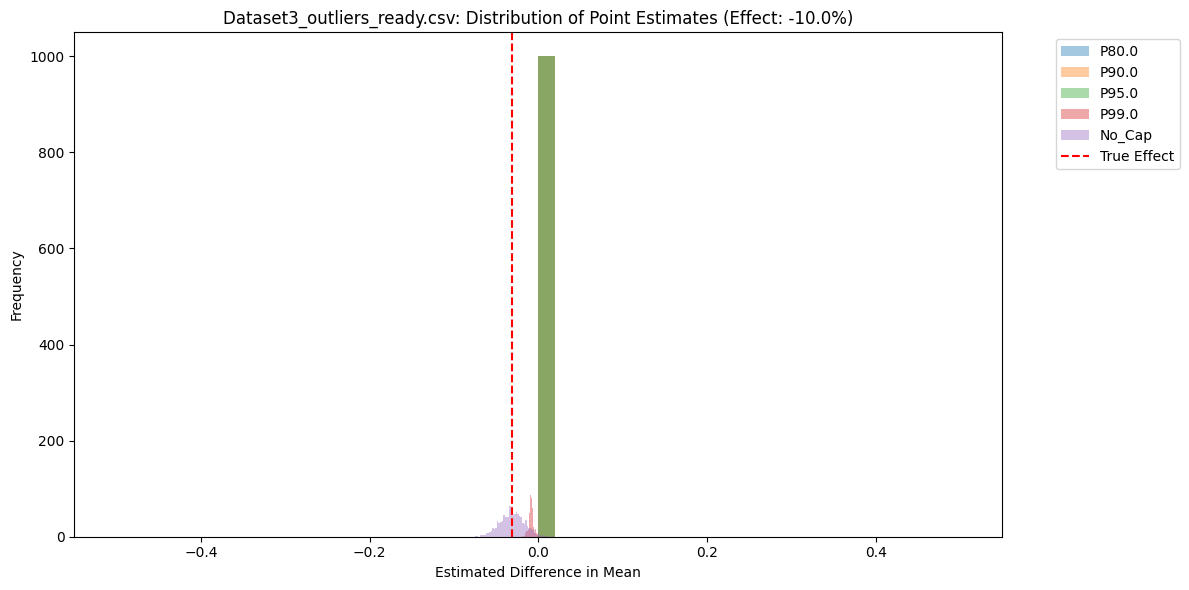

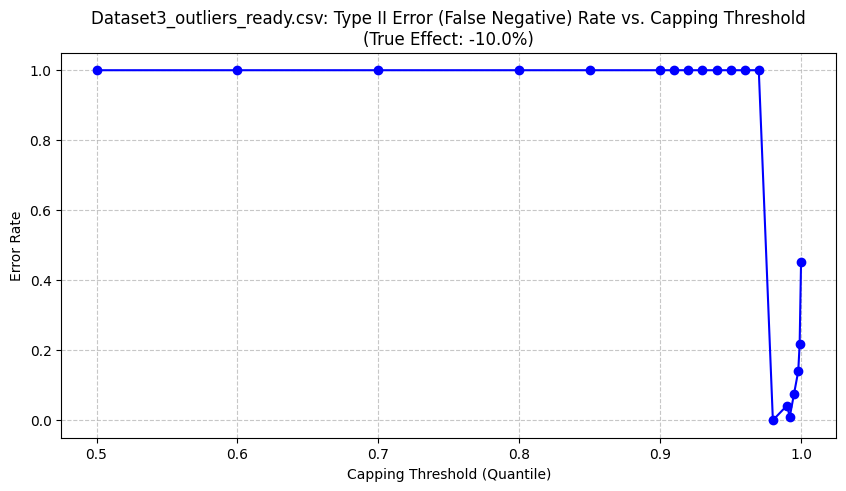

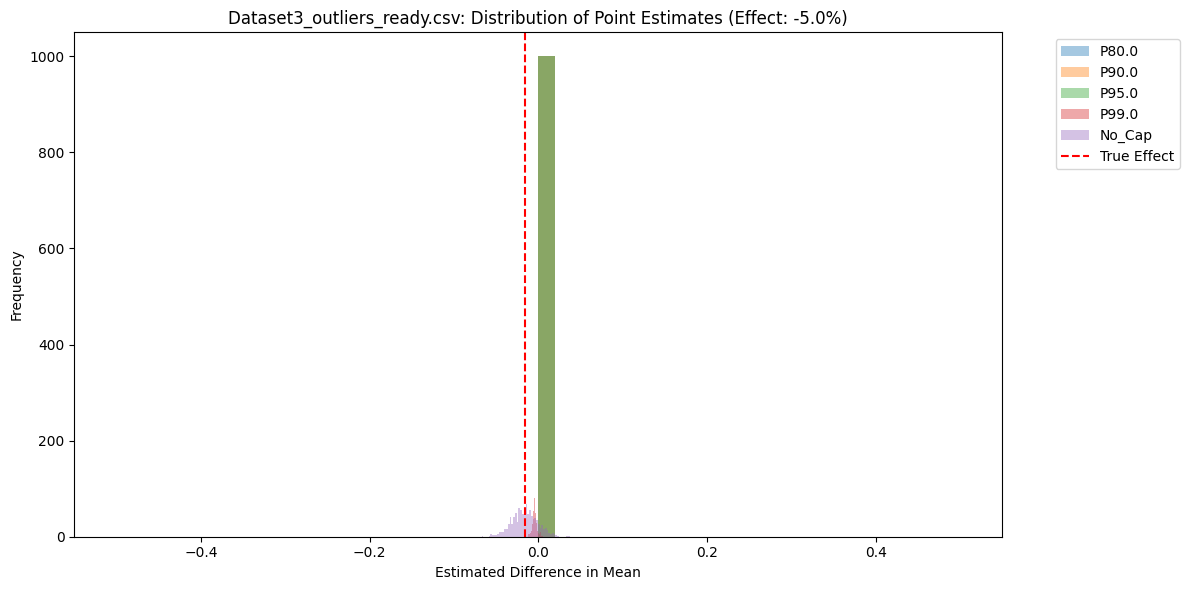

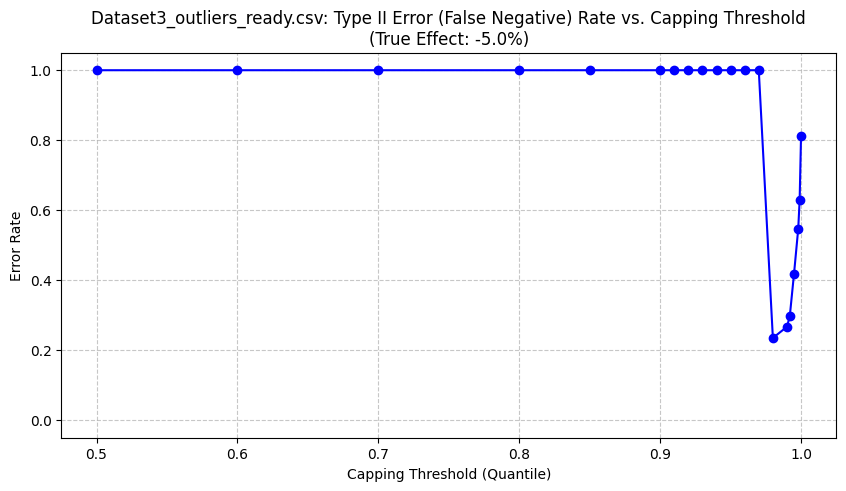

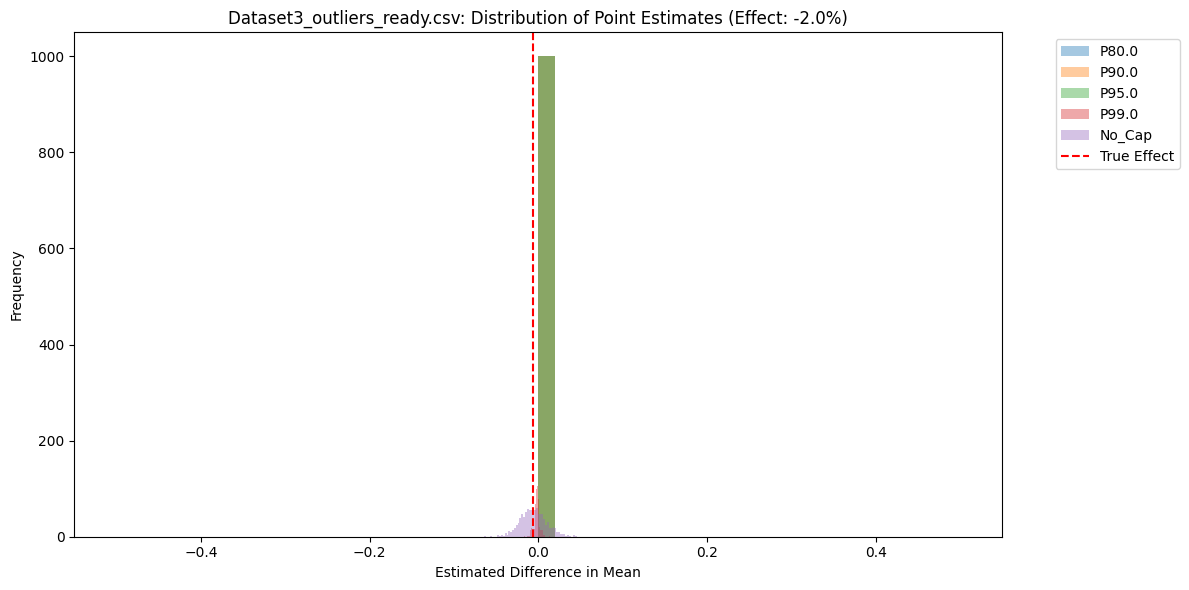

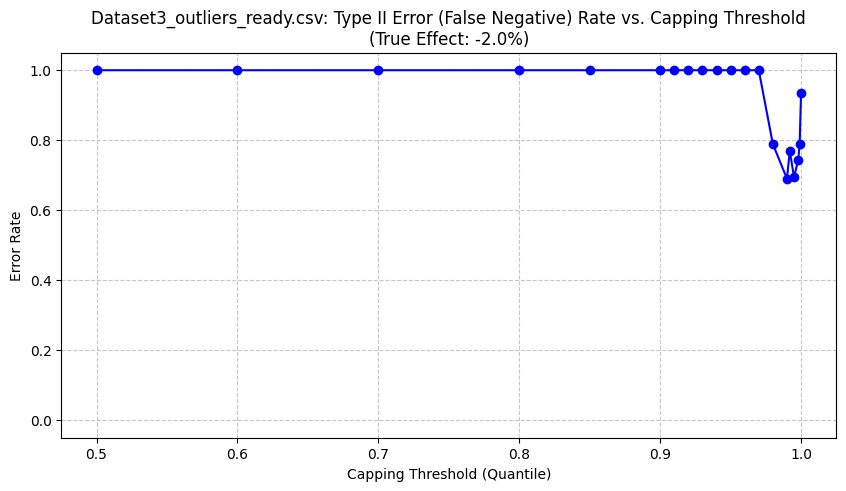

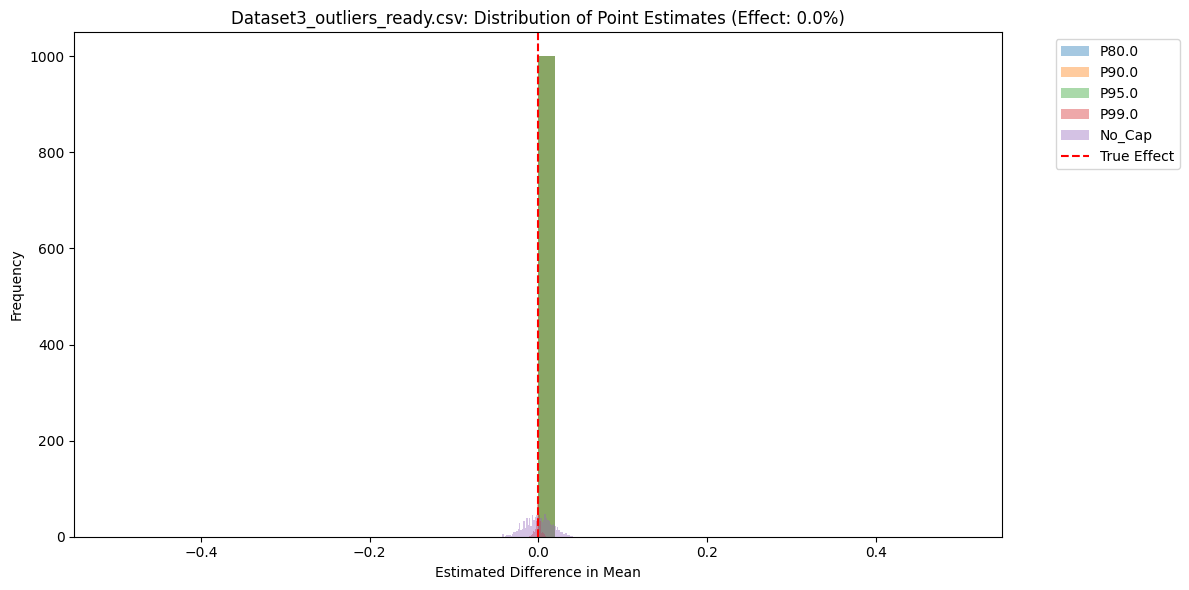

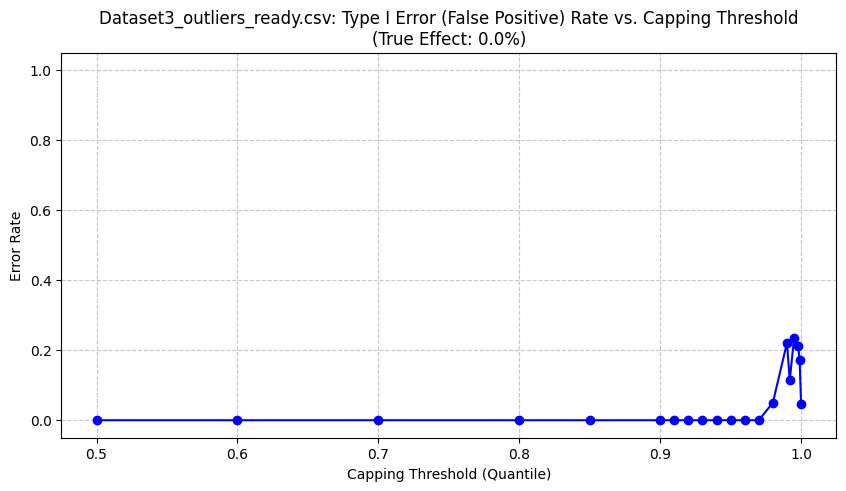

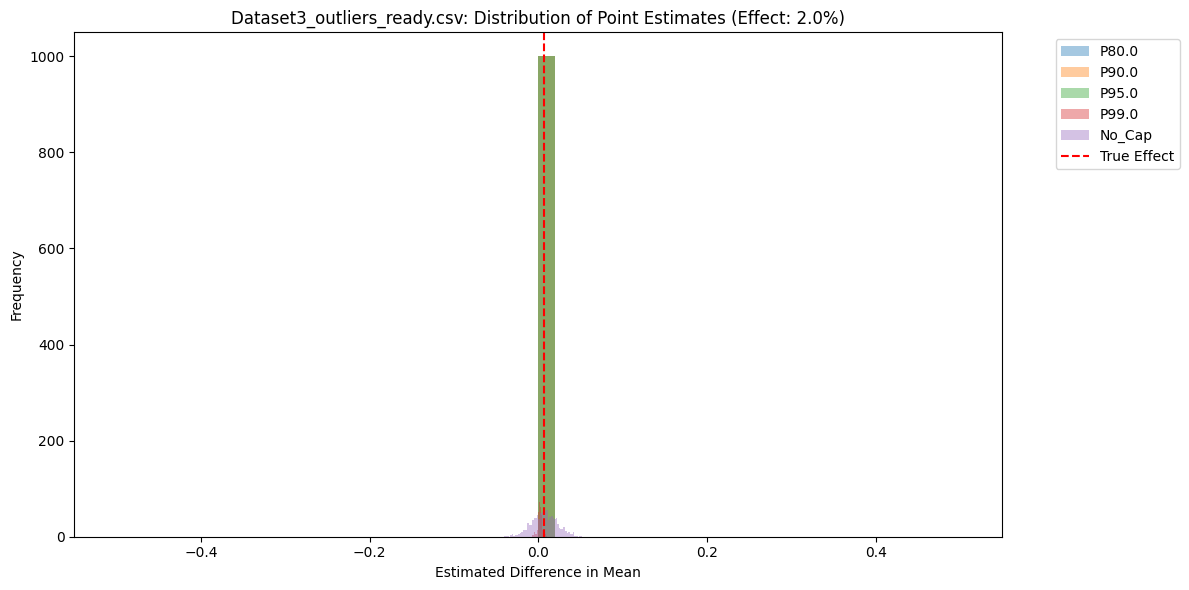

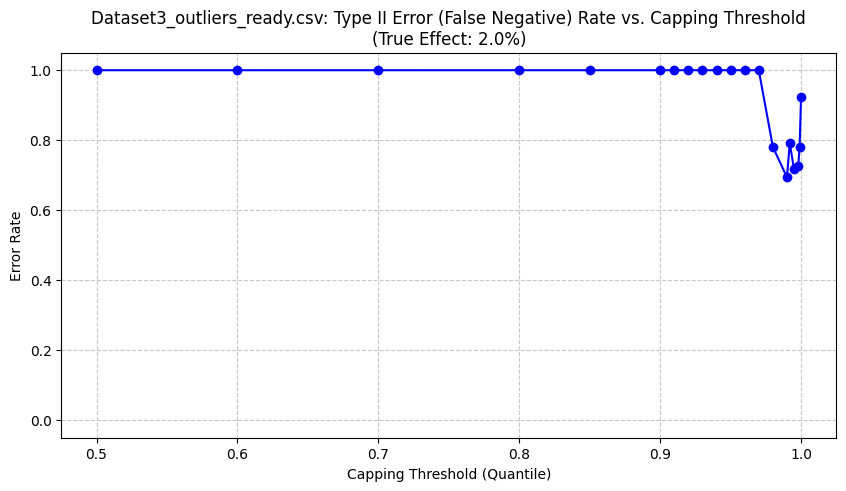

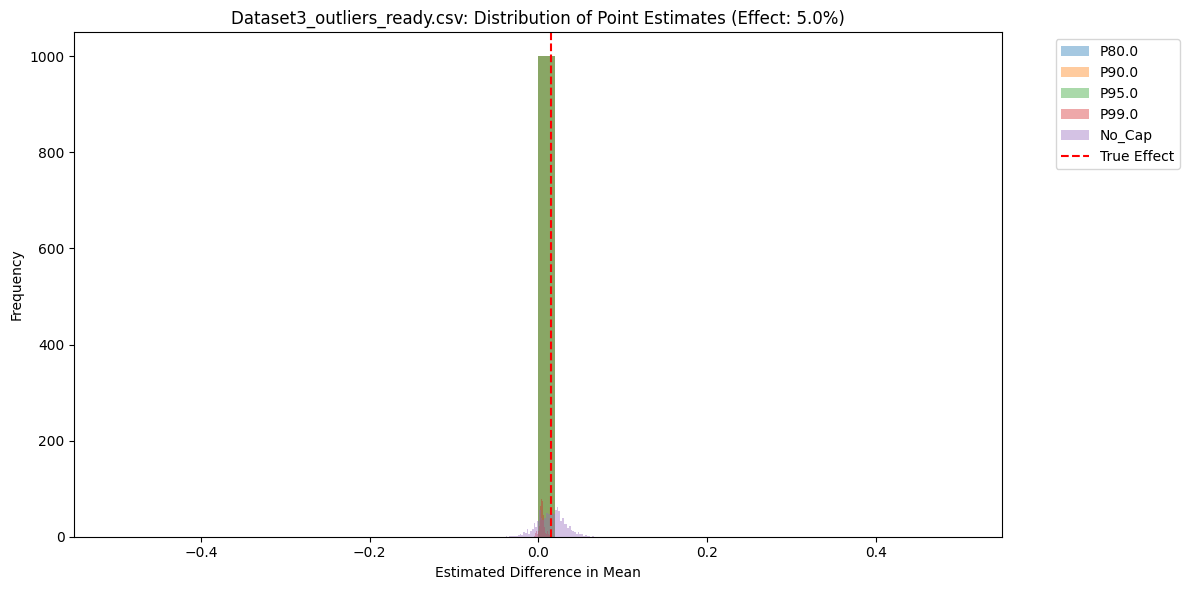

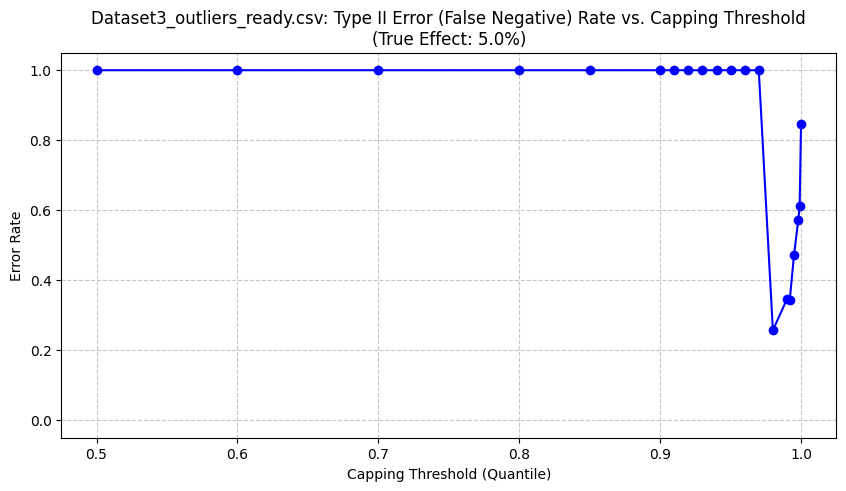

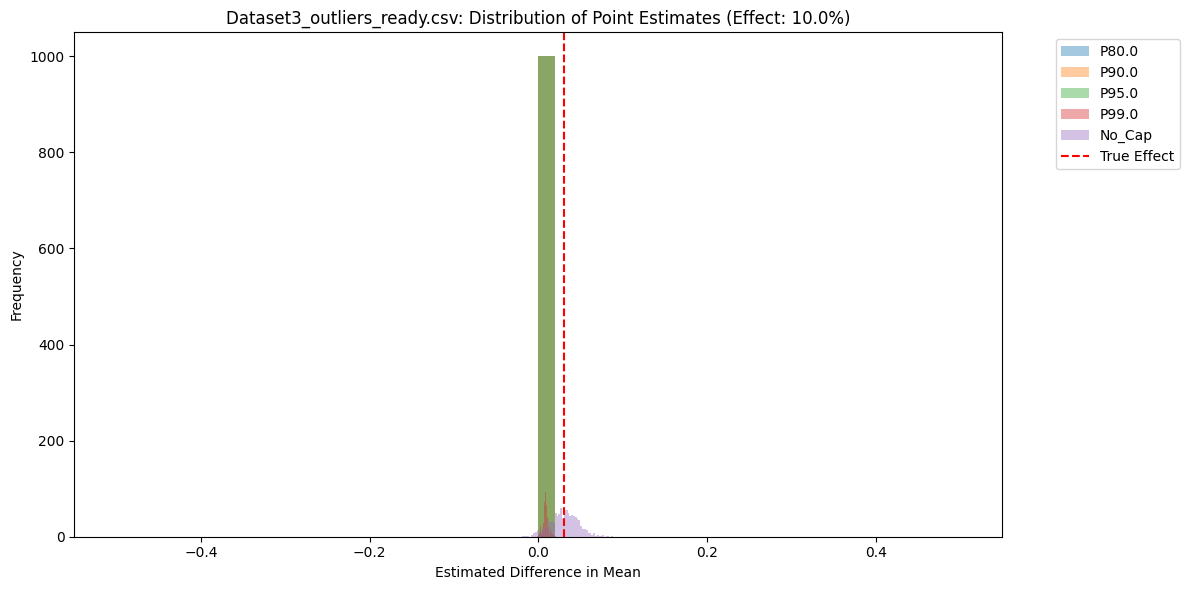

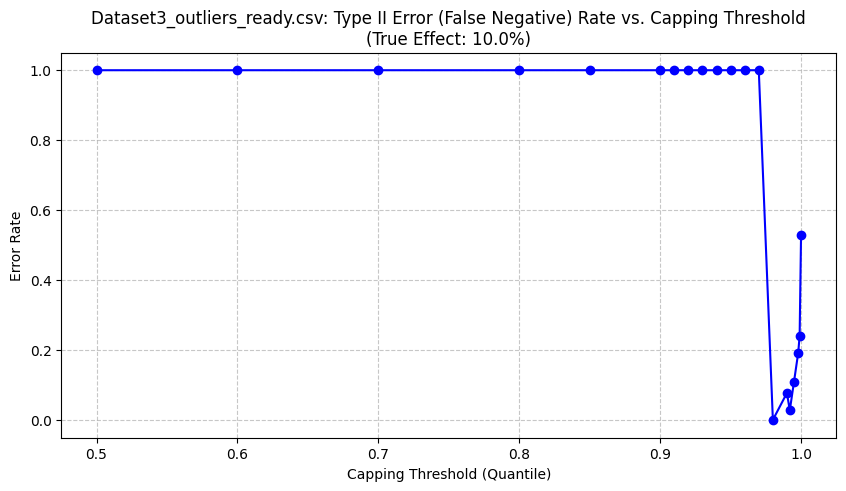

Saved Matrix to experiment3_Dataset3_outliers_ready.csv_matrix.csv
Saved Diagnostics to experiment3_Dataset3_outliers_ready.csv_diagnostics.csv

--- Meta-Analysis ---
Dataset: Dataset3_outliers_ready.csv
Sample_Size: 440519
Original_Mean: 0.3069
Cap Values ($): {'P50.0': 0.0, 'P60.0': 0.0, 'P70.0': 0.0, 'P80.0': 0.0, 'P85.0': 0.0, 'P90.0': 0.0, 'P91.0': 0.0, 'P92.0': 0.0, 'P93.0': 0.0, 'P94.0': 0.0, 'P95.0': 0.0, 'P96.0': 0.0, 'P97.0': 0.0, 'P98.0': 2.02, 'P99.0': 4.65, 'P99.2': 6.04, 'P99.5': 12.08, 'P99.8': 32.49, 'P99.9': 57.87, 'P100.0': inf}

--- Dataset3_outliers_ready.csv Error Matrix ---
 Actual_Effect_Value  P50.0  P60.0  P70.0  P80.0  P85.0  P90.0  P91.0  P92.0  P93.0  P94.0  P95.0  P96.0  P97.0  P98.0  P99.0  P99.2  P99.5  P99.8  P99.9  No_Cap
             -0.0307    1.0    1.0    1.0    1.0    1.0    1.0    1.0    1.0    1.0    1.0    1.0    1.0    1.0  0.000  0.042  0.010  0.075  0.140  0.217   0.451
             -0.0153    1.0    1.0    1.0    1.0    1.0    1.0    1.0    

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

def run_capping_experiment(df, dataset_name, iterations=1000):
    base_revenue = df['REVENUE'].values
    n_total = len(base_revenue)
    mu = np.mean(base_revenue)
    
    # 1. THRESHOLDS
    thresholds = [
        0.50, 0.60, 0.70, 0.80, 0.85, 
        0.90, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 
        0.99, 0.992, 0.995, 0.998, 0.999, 1.0
    ] 
    pct_effects = [-0.10, -0.05, -0.02, 0.0, 0.02, 0.05, 0.10] 
    
    results = []
    detailed_metrics = [] 

    meta_data = {
        "Dataset": dataset_name,
        "Sample_Size": n_total,
        "Original_Mean": round(mu, 4),
        "Caps_Applied": {} 
    }
    
    print(f"\nAnalyzing {dataset_name} with Manual T-Tests...")
    
    for pct in pct_effects:
        actual_delta = mu * pct
        row_results = {'Actual_Effect_Value': round(actual_delta, 4)}
        
        y0 = base_revenue
        # --- Apply the percentage effect individually to each person ---
        y1 = base_revenue * (1 + pct)
        
        # --- Histogram Plot Setup ---
        plt.figure(figsize=(12, 6))
        
        for q in thresholds:
            sig_count = 0
            
            iter_estimates = []
            iter_v1 = []
            iter_v2 = []
            iter_se = []
            iter_tstat = []
            
            if pct == 0.0:
                 ref_cap = np.quantile(y0, q) if q < 1.0 else np.inf
                 meta_data["Caps_Applied"][f"P{q*100}"] = round(ref_cap, 2)

            for _ in range(iterations):
                # 1. Random Assignment
                is_treatment = np.random.rand(n_total) > 0.5
                group_t_raw = y1[is_treatment]
                group_c_raw = y0[~is_treatment]
                
                # 2. Per-group Capping
                if q < 1.0:
                    cap_t = np.quantile(group_t_raw, q)
                    cap_c = np.quantile(group_c_raw, q)
                    gt = np.clip(group_t_raw, None, cap_t)
                    gc = np.clip(group_c_raw, None, cap_c)
                else:
                    gt, gc = group_t_raw, group_c_raw

                # 3. T-test Calculation
                n1, n2 = len(gt), len(gc)
                m1, m2 = np.mean(gt), np.mean(gc)
                v1, v2 = np.var(gt, ddof=1), np.var(gc, ddof=1)
                
                estimate = m1 - m2
                iter_estimates.append(estimate)
                
                se = np.sqrt((v1/n1) + (v2/n2))
                
                if se == 0:
                    p_val = 1.0
                    t_stat = 0.0
                else:
                    t_stat = estimate / se
                    df_welch = ((v1/n1 + v2/n2)**2) / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
                    p_val = stats.t.sf(np.abs(t_stat), df_welch) * 2

                if p_val < 0.05:
                    sig_count += 1
                    
                iter_v1.append(v1)
                iter_v2.append(v2)
                iter_se.append(se)
                iter_tstat.append(t_stat)
            
            success_rate = sig_count / iterations
            col_name = f"P{q*100:.1f}" if q < 1.0 else "No_Cap"
            
            # Error rate logic: Type I error if pct == 0.0, else Type II error
            error_rate = success_rate if pct == 0.0 else 1 - success_rate
            row_results[col_name] = error_rate
            
            detailed_metrics.append({
                "Dataset": dataset_name,
                "True_Pct_Effect": pct,
                "Actual_Effect_Value": actual_delta,
                "Threshold": col_name,
                "Error_Rate": error_rate,
                "Avg_Estimate": np.mean(iter_estimates),
                "Avg_Variance_Treatment": np.mean(iter_v1),
                "Avg_Variance_Control": np.mean(iter_v2),
                "Avg_Standard_Error": np.mean(iter_se),
                "Avg_Abs_T_Stat": np.mean(np.abs(iter_tstat))
            })
            
            if q in [0.80, 0.90, 0.95, 0.99, 1.0]:
                plt.hist(iter_estimates, bins=50, alpha=0.4, label=f'{col_name}')

        plt.axvline(actual_delta, color='red', linestyle='--', label='True Effect')
        plt.title(f"{dataset_name}: Distribution of Point Estimates (Effect: {pct*100}%)")
        plt.xlabel("Estimated Difference in Mean")
        plt.ylabel("Frequency")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        
        # --- Error Movement Line Plot ---
        # Extract the thresholds (x) and error rates (y) for this specific effect
        x_vals = thresholds
        y_vals = [row_results[f"P{q*100:.1f}" if q < 1.0 else "No_Cap"] for q in thresholds]
        
        plt.figure(figsize=(10, 5))
        plt.plot(x_vals, y_vals, marker='o', linestyle='-', color='b', markersize=6)
        error_type = "Type I Error (False Positive)" if pct == 0.0 else "Type II Error (False Negative)"
        plt.title(f"{dataset_name}: {error_type} Rate vs. Capping Threshold\n(True Effect: {pct*100}%)")
        plt.xlabel("Capping Threshold (Quantile)")
        plt.ylabel("Error Rate")
        plt.ylim(-0.05, 1.05)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()
        
        results.append(row_results)

    return pd.DataFrame(results), meta_data, pd.DataFrame(detailed_metrics)

# --- Execution ---
files = [
    '/Users/denghaonan/Desktop/capping/capping_code/Dataset1_outliers_ready.csv', 
    '/Users/denghaonan/Desktop/capping/capping_code/Dataset2_outliers_ready.csv', 
    '/Users/denghaonan/Desktop/capping/capping_code/Dataset3_outliers_ready.csv'
]

for i, file in enumerate(files, 1):
    try:
        data = pd.read_csv(file)
        clean_name = file.split('/')[-1]
        
        # Unpack all 3 returned variables
        report_df, meta, detailed_df = run_capping_experiment(data, clean_name)
        
        # Output 1: Error Matrix
        matrix_filename = f"experiment{i}_{clean_name}_matrix.csv"
        report_df.to_csv(matrix_filename, index=False)
        
        # Output 2: Detailed T-Test Diagnostics
        diagnostics_filename = f"experiment{i}_{clean_name}_diagnostics.csv"
        detailed_df.to_csv(diagnostics_filename, index=False)
        
        print(f"Saved Matrix to {matrix_filename}")
        print(f"Saved Diagnostics to {diagnostics_filename}")
        
        print("\n--- Meta-Analysis ---")
        for k, v in meta.items():
            if k != "Caps_Applied": print(f"{k}: {v}")
        print("Cap Values ($):", meta["Caps_Applied"])
        
        print(f"\n--- {clean_name} Error Matrix ---")
        print(report_df.to_string(index=False))
        print("="*80)
        
    except Exception as e:
        print(f"Failed {file}: {e}")